# Sprint 1 — Task 1: Consolidação da ABT Agrícola BSSL

**Objetivo:** consolidar a Analytical Base Table (ABT) a partir da base *Brazilian Soil Spectral Library — Key Soils* (`BSSL_DB_Key_Soils.xlsx`), aplicar isolamento temporal (OOT), executar split estratificado treino/teste, diagnosticar valores ausentes, gerar análise bivariada e filtrar atributos via Decision Tree rasa.

**Repositório:** issues e pull requests desta sprint são gerenciados em `github.com/vrenzd`.

**Stack:** `pandas`, `numpy`, `seaborn`, `scikit-learn` (`train_test_split`, `DecisionTreeClassifier`), `imblearn` (`RandomUnderSampler`).

---

## Decisões de modelagem assumidas

A tarefa não especifica explicitamente qual é a variável-alvo. Como se trata da fase de **preparação da ABT** (sem etapa de modelagem propriamente dita), a variável-alvo foi definida como **`Region`** (macrorregião brasileira da amostra), pelos seguintes motivos, levantados no próprio diagnóstico de missings feito abaixo:

- `Region` não possui nenhum valor ausente, em nenhuma das partições (treino, teste, OOT).
- Alternativas naturais (`Bioma`, `Geology`, `Vegetation`) têm ausência concentrada em > 90% dos registros mais recentes (janela OOT), inviabilizando validação fora do tempo.
- `Region` é multiclasse e desbalanceada (~4.7% Nordeste vs ~47% Sudeste), o que justifica a etapa de balanceamento pedida no checklist.

Caso a intenção da sprint seja outra variável-alvo, a classe `ConsolidadorABT` abaixo foi parametrizada para trocar o alvo com uma única alteração de constante.

### Isolamento temporal (OOT) — ressalva importante

A base **não contém uma coluna de data/timestamp de coleta**. Como proxy de ordem cronológica, foi utilizado `ID_Unique`, que é estritamente crescente e consistente com blocos de `Owner_code` (lotes de ingestão por laboratório/contribuinte). Os **15% de maior `ID_Unique`** foram isolados como janela OOT. Essa é uma aproximação — não uma data real — e está documentada aqui para transparência metodológica.


## 1. Configuração e imports

In [1]:
import gc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.under_sampling import RandomUnderSampler

sns.set_theme(style='whitegrid', palette='viridis')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

CAMINHO_ARQUIVO = '/mnt/user-data/uploads/BSSL_DB_Key_Soils.xlsx'
ABA_ATRIBUTOS = 'BSSL_Soil_Attributes_Dataset'

COLUNAS_NUMERICAS = ['Sand_gkg', 'Clay_gkg', 'SOM_gkg', 'Ca_mmolkg', 'Mg_mmolkg', 'CEC_Ph7_mmolkg']
COLUNAS_CATEGORICAS = ['Vegetation', 'Bioma', 'Geology', 'Sampling', 'MIR_availability']
COLUNA_ALVO = 'Region'
COLUNA_ORDEM = 'ID_Unique'   # proxy de ordem cronologica (nao ha data explicita na base)

FRACAO_OOT = 0.15
FRACAO_TESTE = 0.30

## 2. Ingestão orientada a objetos (Sample)

Leitura controlada da aba `BSSL_Soil_Attributes_Dataset` com *downcasting* de tipos numéricos e conversão de colunas textuais de baixa cardinalidade para `category`, reduzindo a pegada de memória — importante já que o arquivo completo (incluindo as abas espectrais Vis-NIR-SWIR e MIR) é pesado.

In [2]:
class IngestorABT:
    """Ingestao orientada a objetos com controle de memoria (dtype downcasting)."""

    def __init__(self, caminho_arquivo: str, aba: str):
        self.caminho_arquivo = caminho_arquivo
        self.aba = aba
        self.df_bruto = None

    def carregar(self) -> pd.DataFrame:
        df = pd.read_excel(self.caminho_arquivo, sheet_name=self.aba, engine='openpyxl')
        df = self._otimizar_memoria(df)
        self.df_bruto = df
        return df

    @staticmethod
    def _otimizar_memoria(df: pd.DataFrame) -> pd.DataFrame:
        for col in df.select_dtypes(include=['float64']).columns:
            df[col] = pd.to_numeric(df[col], downcast='float')
        for col in df.select_dtypes(include=['int64']).columns:
            df[col] = pd.to_numeric(df[col], downcast='integer')
        for col in df.select_dtypes(include=['object', 'str']).columns:
            if df[col].nunique(dropna=True) / max(len(df), 1) < 0.5:
                df[col] = df[col].astype('category')
        return df


ingestor = IngestorABT(CAMINHO_ARQUIVO, ABA_ATRIBUTOS)
df_bruto = ingestor.carregar()
print(f'Linhas: {df_bruto.shape[0]:,} | Colunas: {df_bruto.shape[1]}')
print(f'Memoria: {df_bruto.memory_usage(deep=True).sum() / 1024:.1f} KB')
df_bruto.head()

Linhas: 16,084 | Colunas: 20
Memoria: 789.5 KB


,ID_Unique,Owner_code,Vis_NIR_SWIR_availability,MIR_availability,Sampling,Depth_cm,Region,Municipality,State,Vegetation,Bioma,Geology,Sand_gkg,Clay_gkg,SOM_gkg,pH_H2O,Ca_mmolkg,Mg_mmolkg,Na_mmolkg,CEC_Ph7_mmolkg
0,1,EGCO,YES,NO,Auger,0-20,Midwest,Nova Mutum MT,Mato Grosso,Areas of Ecological Tension,Cerrado,Sedimentary Rock,781.0,136.0,24.0,5.2,24.0,8.0,0.1,56.900002
1,2,EGCO,YES,NO,Auger,0-20,Midwest,Nova Mutum MT,Mato Grosso,Areas of Ecological Tension,Cerrado,Sedimentary Rock,767.0,159.0,18.0,5.0,16.0,4.0,0.1,51.900002
2,3,EGCO,YES,NO,Auger,0-20,Midwest,Nova Mutum MT,Mato Grosso,Areas of Ecological Tension,Cerrado,Sedimentary Rock,807.0,141.0,19.0,5.0,18.0,4.0,0.1,45.900002
3,4,EGCO,YES,NO,Auger,0-20,Midwest,Nova Mutum MT,Mato Grosso,Areas of Ecological Tension,Cerrado,Sedimentary Rock,783.0,149.0,20.0,5.5,17.0,3.0,NaN,37.700001
4,5,EGCO,YES,NO,Auger,0-20,Midwest,Nova Mutum MT,Mato Grosso,Areas of Ecological Tension,Cerrado,Sedimentary Rock,766.0,129.0,20.0,5.3,18.0,5.0,0.1,45.799999


## 3. Consolidação da ABT

Colunas removidas da matriz de modelagem e o motivo:

| Coluna | Motivo da exclusão |
|---|---|
| `ID_Unique` | identificador (usado apenas como proxy de ordenação temporal, não como *feature*) |
| `Owner_code` | identificador de contribuinte/lote, sem valor agronômico |
| `Depth_cm` | constante (`0-20` em 100% dos registros) |
| `Vis_NIR_SWIR_availability` | constante (`YES` em 100% dos registros) |
| `State`, `Municipality` | **vazamento direto de rótulo** — determinam `Region` por definição geográfica |
| `Na_mmolkg` | 95,9% de ausência — inviável de imputar com robustez |
| `pH_H2O` | 78,3% de ausência — inviável de imputar com robustez |

Linhas sem `Region` (o alvo) são descartadas — 0 casos no dataset, mas o método já cobre esse cenário para reprodutibilidade.

In [3]:
class ConsolidadorABT:
    """Monta a ABT final: remove identificadores, colunas constantes e colunas com leakage geografico direto."""

    COLUNAS_EXCLUIR = ['ID_Unique', 'Owner_code', 'Depth_cm', 'Vis_NIR_SWIR_availability',
                        'State', 'Municipality', 'Na_mmolkg', 'pH_H2O']

    def __init__(self, colunas_numericas, colunas_categoricas, alvo, coluna_ordem):
        self.colunas_numericas = colunas_numericas
        self.colunas_categoricas = colunas_categoricas
        self.alvo = alvo
        self.coluna_ordem = coluna_ordem

    def consolidar(self, df_bruto: pd.DataFrame) -> pd.DataFrame:
        colunas_finais = [self.coluna_ordem] + self.colunas_numericas + self.colunas_categoricas + [self.alvo]
        abt = df_bruto[colunas_finais].copy()
        abt = abt.dropna(subset=[self.alvo]).reset_index(drop=True)
        return abt

    def diagnostico_missing(self, abt: pd.DataFrame) -> pd.Series:
        relatorio = (abt.isna().mean() * 100).round(2).sort_values(ascending=False)
        return relatorio[relatorio > 0]


consolidador = ConsolidadorABT(COLUNAS_NUMERICAS, COLUNAS_CATEGORICAS, COLUNA_ALVO, COLUNA_ORDEM)
abt = consolidador.consolidar(df_bruto)
print(f'ABT consolidada: {abt.shape[0]:,} linhas x {abt.shape[1]} colunas')
abt.head()

ABT consolidada: 16,084 linhas x 13 colunas


,ID_Unique,Sand_gkg,Clay_gkg,SOM_gkg,Ca_mmolkg,Mg_mmolkg,CEC_Ph7_mmolkg,Vegetation,Bioma,Geology,Sampling,MIR_availability,Region
0,1,781.0,136.0,24.0,24.0,8.0,56.900002,Areas of Ecological Tension,Cerrado,Sedimentary Rock,Auger,NO,Midwest
1,2,767.0,159.0,18.0,16.0,4.0,51.900002,Areas of Ecological Tension,Cerrado,Sedimentary Rock,Auger,NO,Midwest
2,3,807.0,141.0,19.0,18.0,4.0,45.900002,Areas of Ecological Tension,Cerrado,Sedimentary Rock,Auger,NO,Midwest
3,4,783.0,149.0,20.0,17.0,3.0,37.700001,Areas of Ecological Tension,Cerrado,Sedimentary Rock,Auger,NO,Midwest
4,5,766.0,129.0,20.0,18.0,5.0,45.799999,Areas of Ecological Tension,Cerrado,Sedimentary Rock,Auger,NO,Midwest


## 4. Diagnóstico de valores ausentes (Explore)

Ca_mmolkg         22.31
CEC_Ph7_mmolkg    22.31
Mg_mmolkg         22.29
Vegetation        17.51
SOM_gkg           17.02
Geology           16.02
Bioma             16.02
Sampling          12.61
Clay_gkg           6.07
Sand_gkg           5.96
dtype: float64


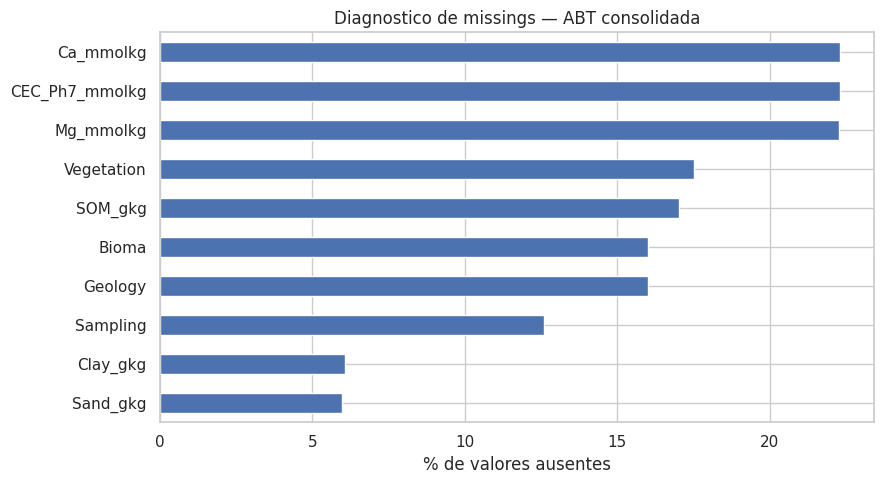

In [4]:
relatorio_missing = consolidador.diagnostico_missing(abt)
print(relatorio_missing)

fig, ax = plt.subplots(figsize=(9, 5))
relatorio_missing.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('% de valores ausentes')
ax.set_title('Diagnostico de missings — ABT consolidada')
plt.tight_layout()
plt.show()

**Leitura do diagnóstico:** os atributos químicos de fertilidade (`Ca_mmolkg`, `Mg_mmolkg`, `CEC_Ph7_mmolkg`, ~22%) e `Vegetation`/`Bioma`/`Geology` (~16–17%) concentram a maior parte da ausência. Como mostrado na introdução, `Bioma`, `Geology` e `Vegetation` têm ausência **fortemente concentrada na janela OOT** (>90%), o que reforça a escolha de `Region` como alvo — e é justamente por isso que essas colunas seguem como *features* explicativas (não como alvo).

## 5. Isolamento temporal (OOT) e split estratificado (Sample)

1. Ordena a ABT por `ID_Unique` (proxy temporal) e reserva os últimos 15% como **OOT**.
2. Sobre o restante (*dev*), aplica `train_test_split` **estratificado por `Region`** (70% treino / 30% teste).

In [5]:
class SplitterTemporal:
    """Isola OOT pela ordem de ingestao (proxy temporal) e faz split treino/teste estratificado no restante."""

    def __init__(self, coluna_ordem, alvo, fracao_oot, fracao_teste, random_state=RANDOM_STATE):
        self.coluna_ordem = coluna_ordem
        self.alvo = alvo
        self.fracao_oot = fracao_oot
        self.fracao_teste = fracao_teste
        self.random_state = random_state

    def separar_oot(self, abt: pd.DataFrame):
        abt_ordenada = abt.sort_values(self.coluna_ordem).reset_index(drop=True)
        corte = int(len(abt_ordenada) * (1 - self.fracao_oot))
        dev = abt_ordenada.iloc[:corte].reset_index(drop=True)
        oot = abt_ordenada.iloc[corte:].reset_index(drop=True)
        return dev, oot

    def split_treino_teste(self, dev: pd.DataFrame):
        treino, teste = train_test_split(
            dev, test_size=self.fracao_teste, stratify=dev[self.alvo], random_state=self.random_state
        )
        return treino.reset_index(drop=True), teste.reset_index(drop=True)


splitter = SplitterTemporal(COLUNA_ORDEM, COLUNA_ALVO, FRACAO_OOT, FRACAO_TESTE)
dev, oot = splitter.separar_oot(abt)
treino, teste = splitter.split_treino_teste(dev)

print(f'Dev (treino+teste): {dev.shape[0]:,} | OOT: {oot.shape[0]:,}')
print(f'Treino: {treino.shape[0]:,} | Teste: {teste.shape[0]:,}')

comparacao = pd.DataFrame({
    'Treino': treino[COLUNA_ALVO].value_counts(normalize=True),
    'Teste': teste[COLUNA_ALVO].value_counts(normalize=True),
    'OOT': oot[COLUNA_ALVO].value_counts(normalize=True),
}).round(3)
comparacao

Dev (treino+teste): 13,671 | OOT: 2,413
Treino: 9,569 | Teste: 4,102


,Treino,Teste,OOT
Region,,,
Midwest,0.244,0.245,0.169
North,0.089,0.088,0.052
Northeast,0.024,0.024,0.116
South,0.166,0.166,0.349
Southeast,0.476,0.476,0.315


**Verificação da estratificação:** as proporções de `Region` em Treino e Teste ficam praticamente idênticas (diferença ≤ 0,1 p.p. por classe), confirmando que o `stratify=` funcionou corretamente.

**Achado relevante para o negócio:** a distribuição do alvo na janela **OOT diverge** da distribuição em Treino/Teste (ex.: `South` passa a ser a região mais frequente na OOT, e `Southeast` cai de ~47% para ~31%). Isso é evidência de *drift* populacional ao longo da ordem de ingestão da base — exatamente o tipo de risco que a validação OOT existe para capturar antes de um modelo ir para produção.

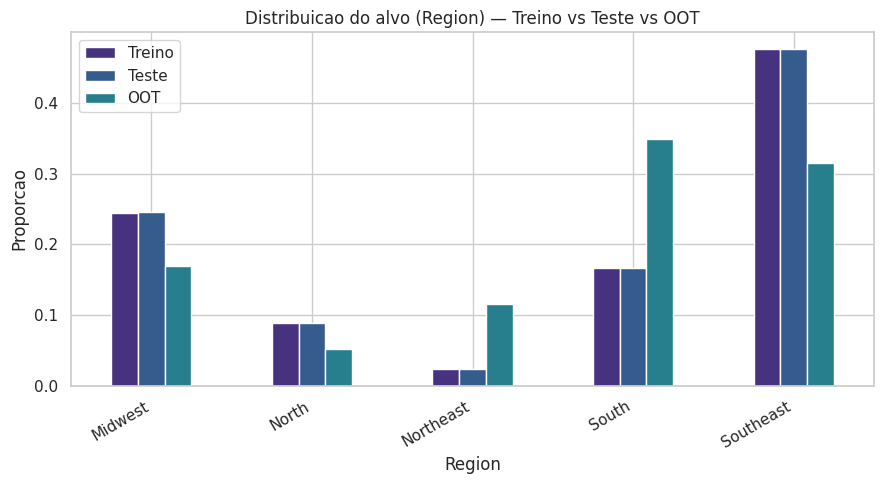

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
comparacao.plot(kind='bar', ax=ax)
ax.set_ylabel('Proporcao')
ax.set_title('Distribuicao do alvo (Region) — Treino vs Teste vs OOT')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 6. Análise bivariada (Explore)

Bivariada calculada **apenas sobre o treino**, para não vazar informação da OOT/teste na fase exploratória.

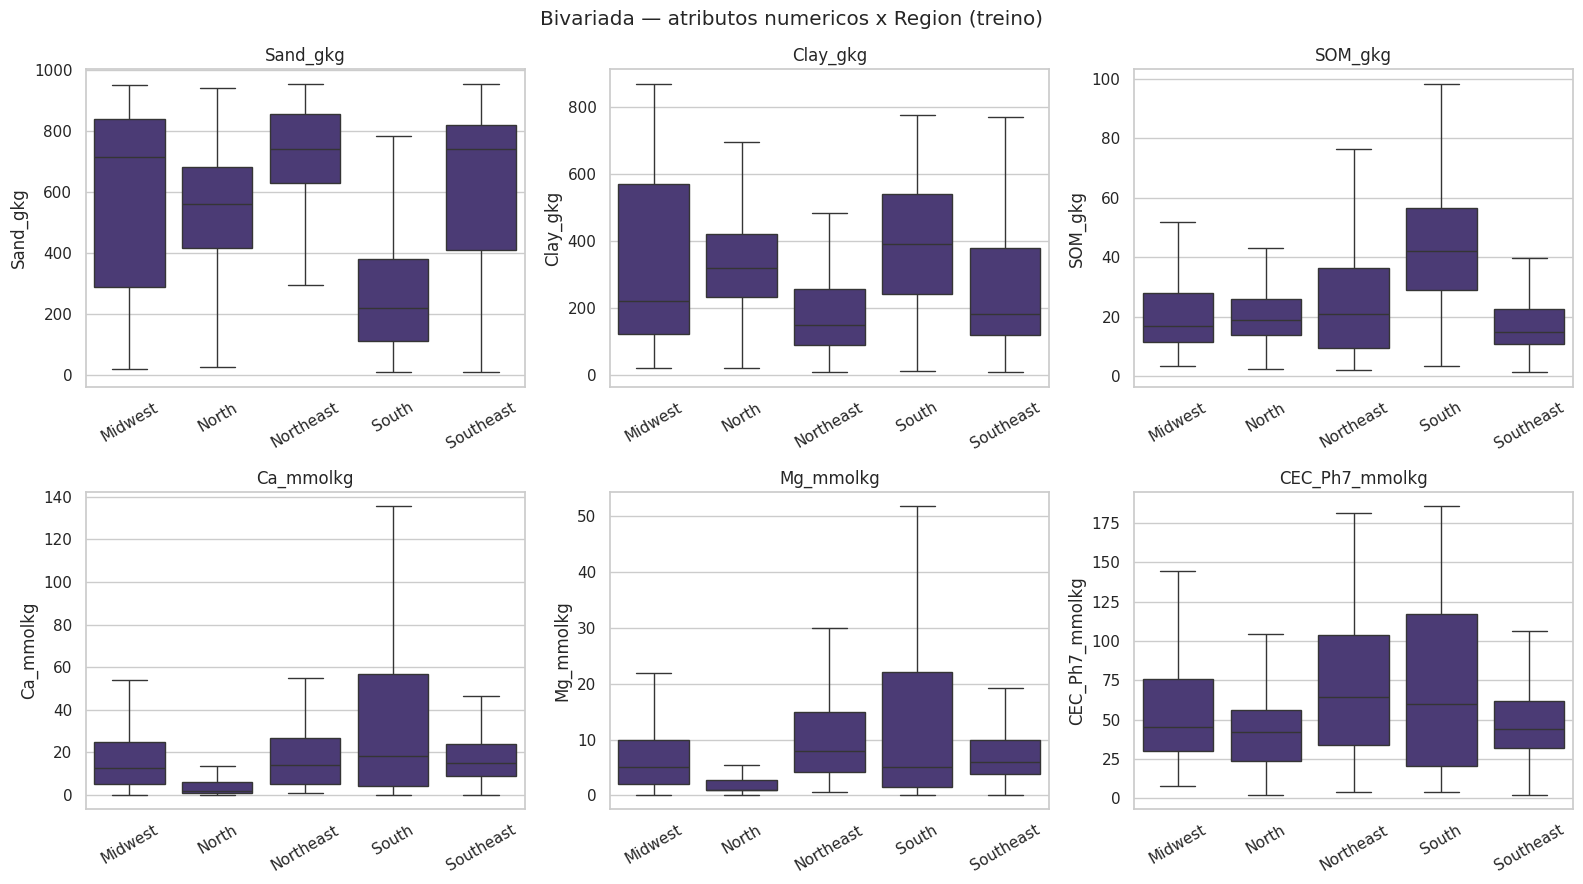

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), COLUNAS_NUMERICAS):
    sns.boxplot(data=treino, x=COLUNA_ALVO, y=col, ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Bivariada — atributos numericos x Region (treino)')
plt.tight_layout()
plt.show()

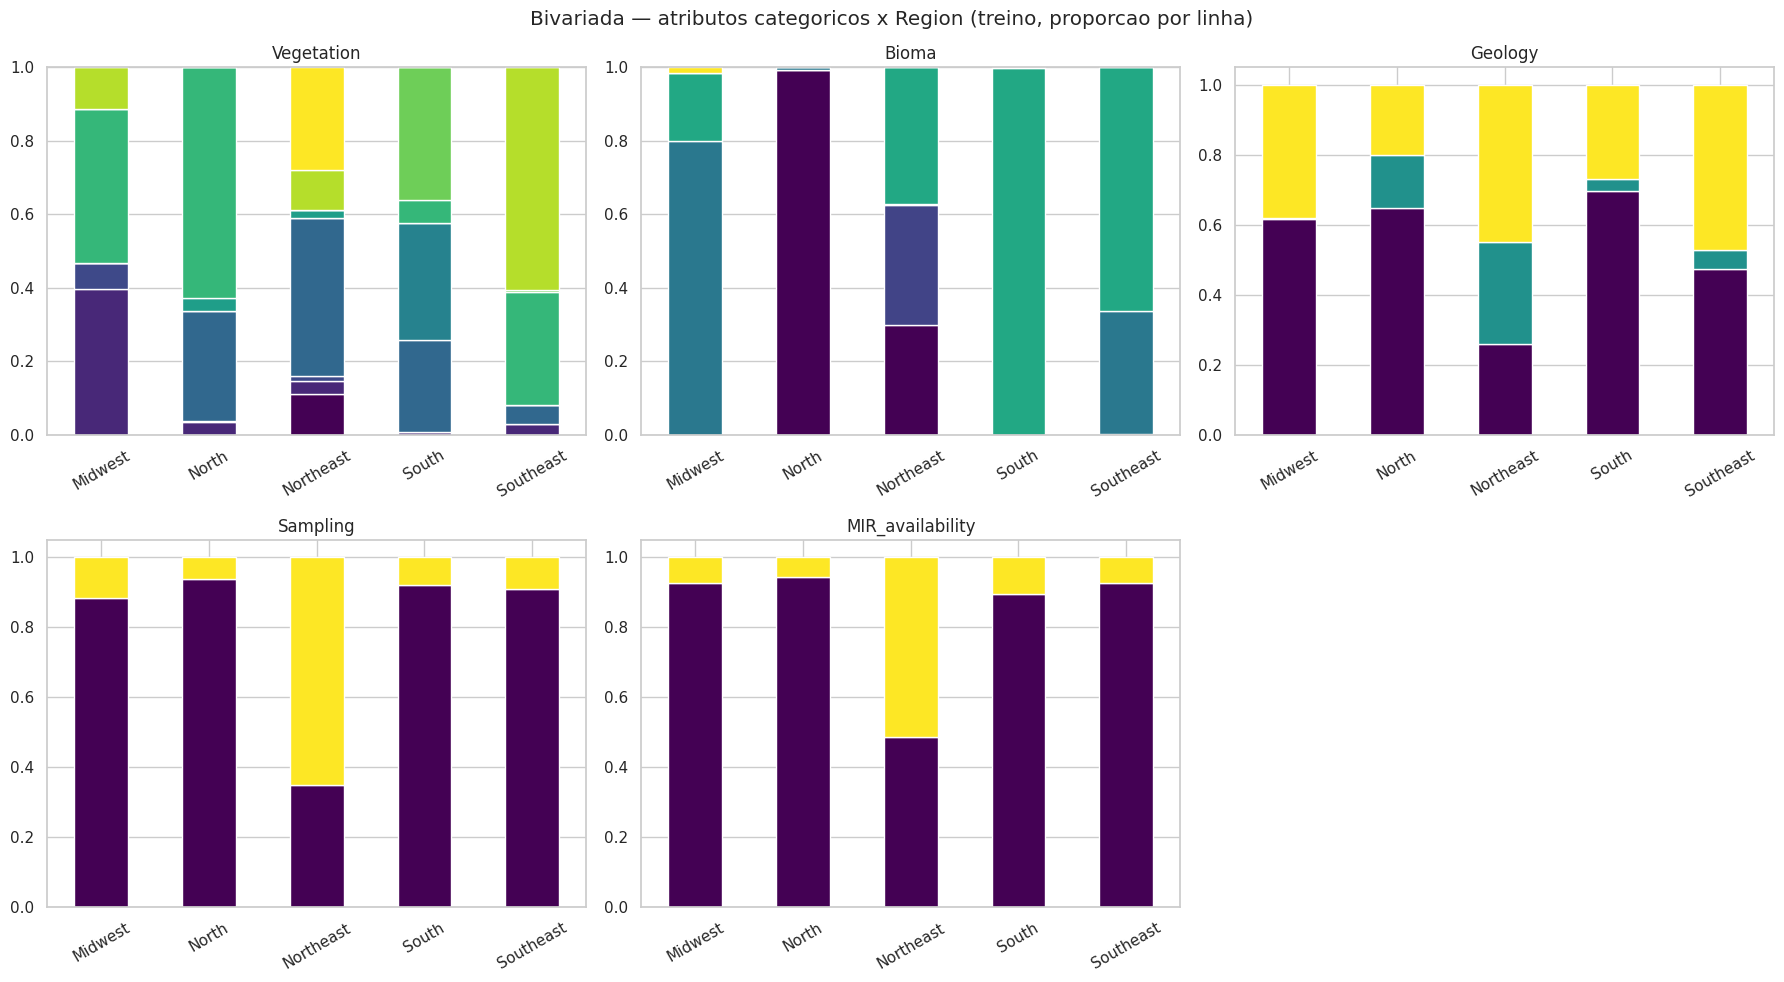

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), COLUNAS_CATEGORICAS):
    tab = pd.crosstab(treino[COLUNA_ALVO], treino[col], normalize='index')
    tab.plot(kind='bar', stacked=True, ax=ax, legend=False, colormap='viridis')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
axes.ravel()[-1].axis('off')
plt.suptitle('Bivariada — atributos categoricos x Region (treino, proporcao por linha)')
plt.tight_layout()
plt.show()

**Leitura rápida da bivariada:**
- `Bioma` e `Geology` mostram forte associação com `Region` (ex.: `Amazonia` concentrada em `North`/`Midwest`), o que é esperado geograficamente — e antecipa que essas variáveis dominem a importância na árvore de decisão a seguir.
- Entre os atributos físico-químicos, `Clay_gkg` e `Mg_mmolkg` mostram as distribuições mais diferenciadas entre regiões; `Sand_gkg` e `SOM_gkg` são mais sobrepostos entre classes.

## 7. Tratamento de valores ausentes (Modify)

Estatísticas de imputação (mediana) são **ajustadas somente no treino** e aplicadas a treino/teste/OOT — evitando vazamento de informação das partições de avaliação. Para cada numérico, uma *flag* binária `_ausente` é criada antes da imputação, preservando o padrão de ausência como sinal. Categóricos ausentes recebem a categoria explícita `'Desconhecido'`.

In [9]:
class TratadorAusentes:
    """Ajusta estatisticas apenas no treino e aplica em treino/teste/oot (sem vazamento)."""

    def __init__(self, colunas_numericas, colunas_categoricas):
        self.colunas_numericas = colunas_numericas
        self.colunas_categoricas = colunas_categoricas
        self.medianas_ = {}

    def fit(self, treino: pd.DataFrame):
        self.medianas_ = {c: treino[c].median() for c in self.colunas_numericas}
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        for c in self.colunas_numericas:
            df[f'{c}_ausente'] = df[c].isna().astype('int8')
            df[c] = df[c].fillna(self.medianas_[c])
        for c in self.colunas_categoricas:
            if str(df[c].dtype) == 'category' and 'Desconhecido' not in df[c].cat.categories:
                df[c] = df[c].cat.add_categories(['Desconhecido'])
            df[c] = df[c].fillna('Desconhecido')
        return df


tratador = TratadorAusentes(COLUNAS_NUMERICAS, COLUNAS_CATEGORICAS)
tratador.fit(treino)

treino_tratado = tratador.transform(treino)
teste_tratado = tratador.transform(teste)
oot_tratado = tratador.transform(oot)

print('Ausentes restantes apos tratamento (treino/teste/oot):',
      treino_tratado.isna().sum().sum(), teste_tratado.isna().sum().sum(), oot_tratado.isna().sum().sum())

COLUNAS_FLAG_AUSENTE = [f'{c}_ausente' for c in COLUNAS_NUMERICAS]
COLUNAS_FEATURES = COLUNAS_NUMERICAS + COLUNAS_FLAG_AUSENTE + COLUNAS_CATEGORICAS

Ausentes restantes apos tratamento (treino/teste/oot): 0 0 0


## 8. Balanceamento restrito ao treino (Modify)

`RandomUnderSampler` é aplicado **exclusivamente sobre `treino_tratado`**. Teste e OOT permanecem com a distribuição original de `Region`, pois precisam refletir a realidade que o modelo encontrará em produção.

In [10]:
class BalanceadorTreino:
    """Undersampling aleatorio restrito EXCLUSIVAMENTE ao conjunto de treino."""

    def __init__(self, alvo, random_state=RANDOM_STATE):
        self.alvo = alvo
        self.random_state = random_state

    def balancear(self, treino: pd.DataFrame, colunas_features: list) -> pd.DataFrame:
        X = treino[colunas_features]
        y = treino[self.alvo]
        rus = RandomUnderSampler(random_state=self.random_state)
        X_bal, y_bal = rus.fit_resample(X, y)
        treino_balanceado = X_bal.copy()
        treino_balanceado[self.alvo] = y_bal.values
        return treino_balanceado


balanceador = BalanceadorTreino(COLUNA_ALVO)
treino_balanceado = balanceador.balancear(treino_tratado, COLUNAS_FEATURES)

print(f'Treino original: {treino_tratado.shape[0]:,} linhas | Treino balanceado: {treino_balanceado.shape[0]:,} linhas')
treino_balanceado[COLUNA_ALVO].value_counts()

Treino original: 9,569 linhas | Treino balanceado: 1,160 linhas


Region
Midwest      232
North        232
Northeast    232
South        232
Southeast    232
Name: count, dtype: int64

**Nota de metodologia:** `Northeast` é a classe minoritária no treino (~2,4% dos casos), então o `RandomUnderSampler` reduz todas as demais classes a esse tamanho. Isso garante balanceamento perfeito, mas descarta uma quantidade grande de observações das classes majoritárias — *trade-off* típico do undersampling puro, a ser revisitado na próxima sprint (candidatos: undersampling parcial, ou combinação com oversampling sintético).

## 9. Filtragem de atributos via Decision Tree rasa (Modify)

Árvore de decisão com profundidade limitada (`max_depth=4`), treinada sobre o **treino balanceado** (categóricas *one-hot*), usada apenas como filtro de importância de atributos — não como modelo final.

In [11]:
class SeletorArvoreRasa:
    """Filtra atributos via importancia de uma Decision Tree rasa treinada no treino balanceado."""

    def __init__(self, alvo, max_depth=4, random_state=RANDOM_STATE):
        self.alvo = alvo
        self.max_depth = max_depth
        self.random_state = random_state
        self.modelo_ = None
        self.importancias_ = None

    def ajustar(self, treino_codificado: pd.DataFrame, colunas_features: list) -> pd.Series:
        X = treino_codificado[colunas_features]
        y = treino_codificado[self.alvo]
        self.modelo_ = DecisionTreeClassifier(max_depth=self.max_depth, random_state=self.random_state)
        self.modelo_.fit(X, y)
        self.importancias_ = pd.Series(
            self.modelo_.feature_importances_, index=colunas_features
        ).sort_values(ascending=False)
        return self.importancias_

    def selecionar(self, limiar: float = 0.0) -> list:
        return self.importancias_[self.importancias_ > limiar].index.tolist()


treino_codificado = pd.get_dummies(treino_balanceado[COLUNAS_FEATURES], columns=COLUNAS_CATEGORICAS)
treino_codificado[COLUNA_ALVO] = treino_balanceado[COLUNA_ALVO].values
colunas_codificadas = [c for c in treino_codificado.columns if c != COLUNA_ALVO]

seletor = SeletorArvoreRasa(COLUNA_ALVO, max_depth=4)
importancias = seletor.ajustar(treino_codificado, colunas_codificadas)
atributos_selecionados = seletor.selecionar(limiar=0.0)

print(f'{len(atributos_selecionados)} de {len(colunas_codificadas)} atributos com importancia > 0')
importancias

12 de 40 atributos com importancia > 0


Bioma_Amazonia                              0.316399
Sampling_Desconhecido                       0.242132
Sand_gkg_ausente                            0.126274
Vegetation_Seasonal Semideciduous Forest    0.126090
Mg_mmolkg                                   0.094372
Clay_gkg                                    0.033236
Vegetation_Savannah                         0.025840
Sampling_Auger                              0.018709
SOM_gkg                                     0.008859
SOM_gkg_ausente                             0.003486
Ca_mmolkg                                   0.003454
CEC_Ph7_mmolkg                              0.001151
Clay_gkg_ausente                            0.000000
Sand_gkg                                    0.000000
Vegetation_Amazon Rainforest                0.000000
Ca_mmolkg_ausente                           0.000000
Vegetation_Dense Ombrophylous Forest        0.000000
Vegetation_Areas of Pioneering Formation    0.000000
Vegetation_Areas of Ecological Tension      0.

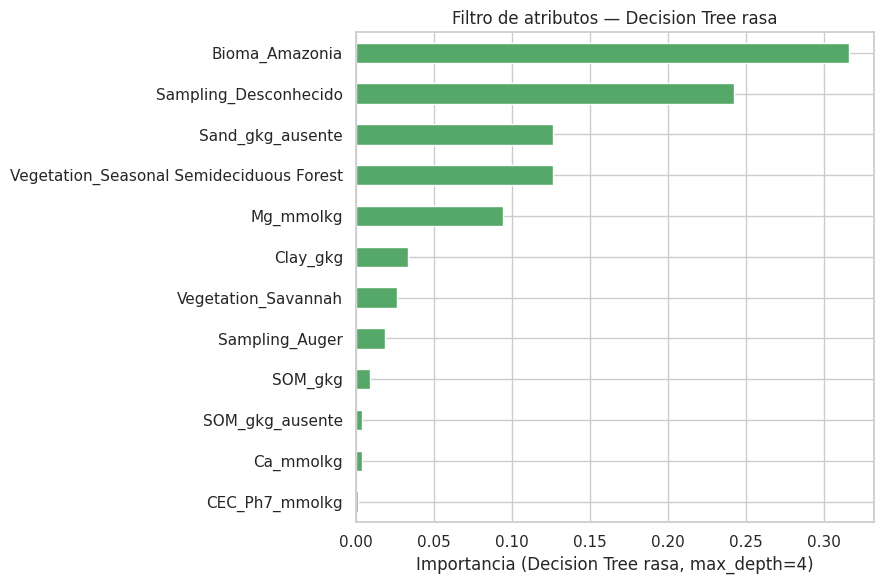

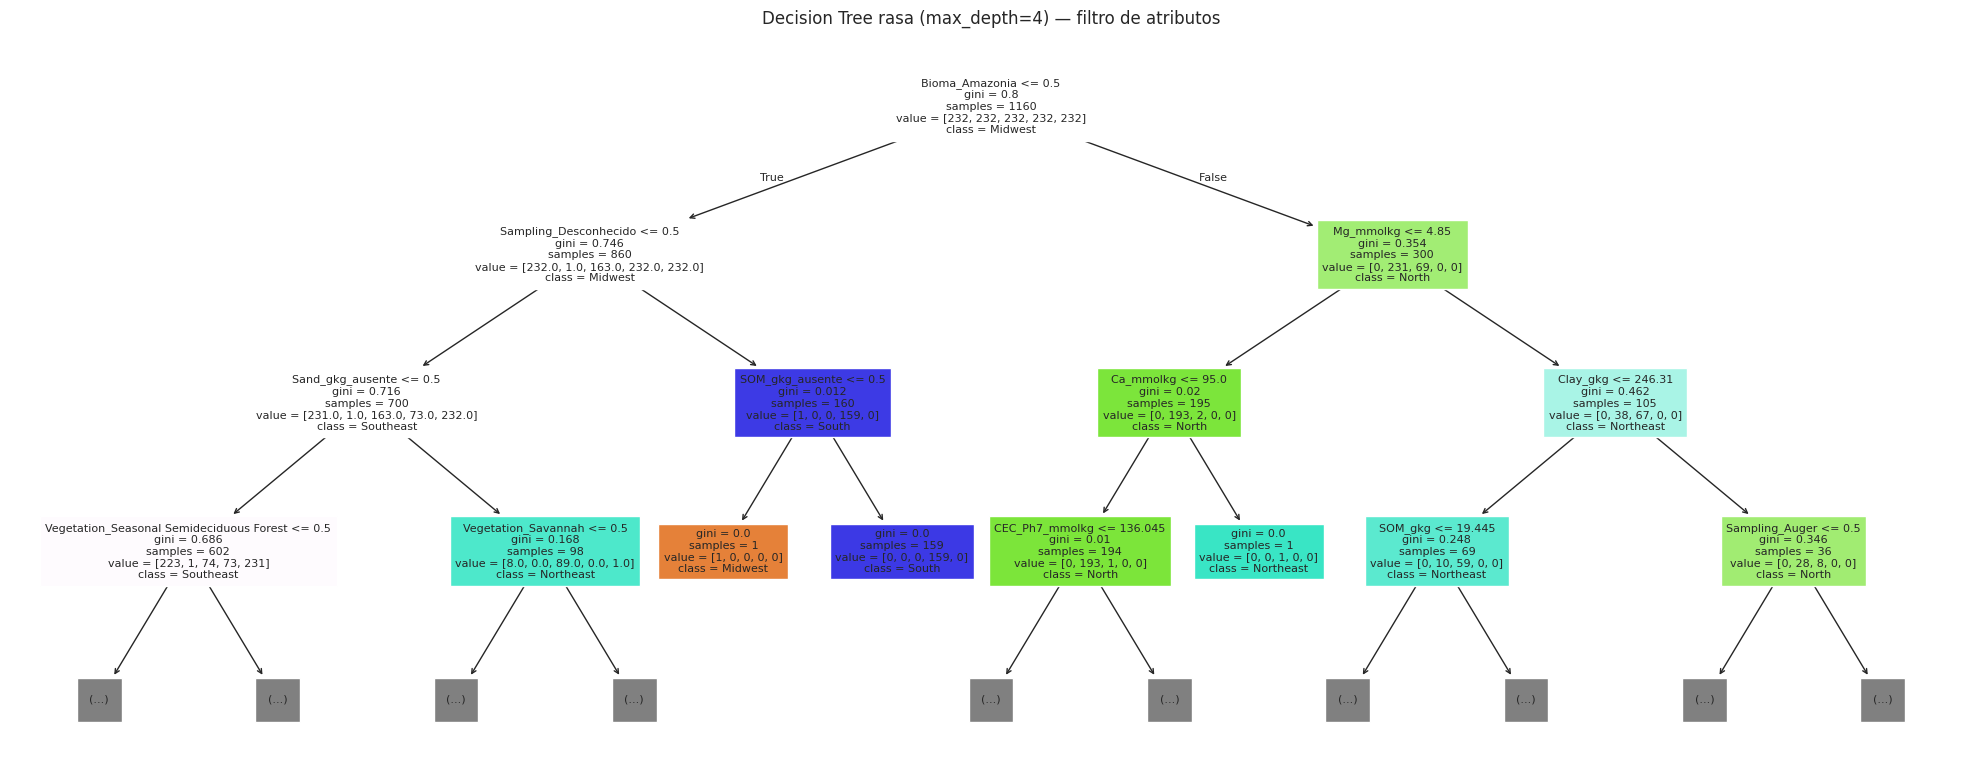

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
importancias[importancias > 0].sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_xlabel('Importancia (Decision Tree rasa, max_depth=4)')
ax.set_title('Filtro de atributos — Decision Tree rasa')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(seletor.modelo_, feature_names=colunas_codificadas, class_names=seletor.modelo_.classes_,
          filled=True, max_depth=3, fontsize=8, ax=ax)
ax.set_title('Decision Tree rasa (max_depth=4) — filtro de atributos')
plt.tight_layout()
plt.show()

**Leitura do filtro:** `Bioma_Amazonia` isolada é o atributo de maior poder discriminante — coerente com a bivariada, já que o bioma Amazônia está quase inteiramente contido nas regiões `North`/`Midwest`. Em seguida aparecem `Sampling_Desconhecido` (padrão de ausência), `Sand_gkg_ausente`, `Vegetation_Seasonal Semideciduous Forest`, `Mg_mmolkg` e `Clay_gkg`. Atributos com importância zero (ex.: a maioria das categorias de `Geology` e `MIR_availability`) podem ser descartados da matriz final sem perda de poder preditivo nesta árvore rasa.

## 10. Consolidação final e exportação dos artefatos

Exporta as três partições da ABT (schema completo, pós-tratamento de ausentes, pré-balanceamento) e o treino balanceado, todos como CSV — entregável desta task.

In [13]:
import os

PASTA_SAIDA = '/mnt/user-data/outputs'
os.makedirs(PASTA_SAIDA, exist_ok=True)

treino_tratado.to_csv(f'{PASTA_SAIDA}/abt_treino.csv', index=False)
teste_tratado.to_csv(f'{PASTA_SAIDA}/abt_teste.csv', index=False)
oot_tratado.to_csv(f'{PASTA_SAIDA}/abt_oot.csv', index=False)
treino_balanceado.to_csv(f'{PASTA_SAIDA}/abt_treino_balanceado.csv', index=False)

resumo = pd.DataFrame({
    'Particao': ['Treino', 'Teste', 'OOT', 'Treino (balanceado)'],
    'Linhas': [len(treino_tratado), len(teste_tratado), len(oot_tratado), len(treino_balanceado)],
    'Classes_do_alvo': [treino_tratado[COLUNA_ALVO].nunique()] * 4,
})
resumo

,Particao,Linhas,Classes_do_alvo
0,Treino,9569,5
1,Teste,4102,5
2,OOT,2413,5
3,Treino (balanceado),1160,5


## 11. Relatório EDA — síntese

- **ABT consolidada:** 16.084 registros → 13.671 (dev) + 2.413 (OOT) após isolamento temporal por `ID_Unique`; 0 registros perdidos por ausência de alvo (`Region` sempre preenchido).
- **Missing:** concentrado em atributos químicos (~19–22%) e em `Bioma`/`Geology`/`Vegetation` (~16–18%), sendo que estes últimos ficam **quase totalmente ausentes na janela OOT** — motivo pelo qual não foram usados como alvo.
- **Split:** treino (9.569) / teste (4.102), estratificado por `Region`, com proporções praticamente idênticas entre as duas partições.
- **Drift OOT:** a distribuição de `Region` na OOT diverge visivelmente da distribuição em treino/teste — sinal de mudança populacional ao longo da ordem de ingestão da base, a acompanhar de perto ao avaliar qualquer modelo treinado nesta ABT.
- **Balanceamento:** `RandomUnderSampler` aplicado só ao treino, reduzindo todas as classes ao tamanho da minoritária (`Northeast`, 232 casos) — treino balanceado final com 1.160 linhas.
- **Filtro de atributos:** árvore rasa aponta `Bioma`, o padrão de ausência de `Sampling`/`Sand_gkg` e `Vegetation` como os sinais mais fortes; várias categorias de `Geology` e `MIR_availability` têm importância nula e são candidatas a descarte.

### Próximos passos sugeridos (backlog da sprint)
1. Avaliar undersampling parcial ou combinação com oversampling sintético para reduzir a perda de dados do treino.
2. Investigar a causa do drift entre dev e OOT (mudança de contribuintes/laboratórios ao longo do tempo de ingestão).
3. Treinar e validar um classificador completo sobre a ABT filtrada, com a OOT como teste final de generalização.